In [1]:
import pandas as pd              # Para análisis de datos
import numpy as np               # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para gráficos
import seaborn as sns            # Para gráficos bonitos

Tenemos una funcion $\frac{dy(t)}{dt} = f(t,y)$ y queremos hallar $y(t)$. El recetario de RK4 es:

$y(t_{k+1}) = y(t_{k}) + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$

con:

$k_1 = f(t_k,y(t_k))$ 

$k_2 = f(t_k + \frac{h}{2},y(t_k) + \frac{h}{2}k_1)$

$k_3 = f(t_k + \frac{h}{2},y(t_k) + \frac{h}{2}k_2)$

$k_4 = f(t_k + h,y(t_k) + hk_3)$

Para realizar la funcion RK4 necesitamos conocer $f(t,y)$, $t_0$, $t_1$, $y(t_0) = y_0$ y el tamaño del paso $h$. La implementacion de lo anterior es:

In [2]:
def yt(func,t0,t1,y0,h):
    # func = f(t,y(t))
    # t0 = valor incial
    # y0 = y(t0) limite inferior de t
    # y1 = limite superior de t
    # h = tamaño del paso

    N = int((t1-t0) / h) # Numero de subdivisiones

    y = np.zeros(N+1) #Pongo N+1 ya que luego en el bucle for llegamos hasta k+1 y si no se sale de rango
    t = np.zeros(N+1)

    y[0] = y0 
    t[0] = t0 

    for k in range (0,N,1):
        k1 = func(t[k],y[k])
        k2 = func(t[k] + h/2,y[k] + (h/2)*k1)
        k3 = func(t[k] + h/2,y[k] + (h/2)*k2)
        k4 = func(t[k] + h,y[k] + h*k3)
        y[k+1] = y[k] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        t[k+1] = t[0] + (k+1) * h  # Efectivamente para k = N-1 recuperamos t1 = t0 + h*N

    return t,y

El programa principal (en el que planteamos el problema a resolver conociendo $f(t,y)$) es el siguiente.

El problema es $\frac{dy}{dt} = f(t,y) = y - t^2 + 1$ para $0 \leq t \leq 2$ y sabiendo que $y(0) = 0.5$.

In [3]:
def f(t,y): # dy/dt = f(t,y)
    valor = y - t**2 + 1
    return valor

t0=0
t1=2
y0=0.5 # y(0)=0.5
h = 0.1

t,y = yt(f,t0,t1,y0,h) # Solucion numerica y(t)

Podemos comparar con la solucion exacta que es $y(t) = (t+1)^2 - 0.5 e^{t}$ :

In [4]:
def sol_exac_y(t): # y(t) exacto (solucion simbolica)
    valor = (t+1)**2 - 0.5*(np.e**(t))
    return valor

La comprobacion grafica es la siguiente: 

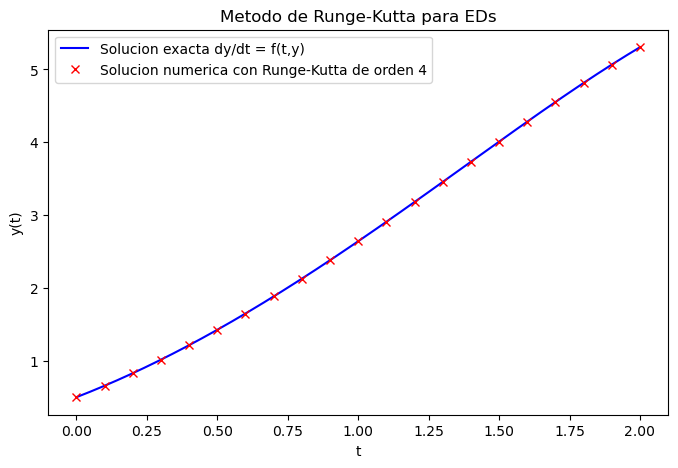

In [5]:
t_vals = np.linspace(t0, t1, 500) 
y_vals = sol_exac_y(t_vals)

plt.figure(figsize=(8, 5))
plt.plot(t_vals, y_vals, label='Solucion exacta dy/dt = f(t,y)', color='blue')
plt.plot(t, y, 'x',label='Solucion numerica con Runge-Kutta de orden 4', color='red')
plt.title('Metodo de Runge-Kutta para EDs')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(False)
plt.show()